In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/diabetes.csv")

In [2]:
# Print first 10 rows
print("First 10 rows of dataset:")
print(df.head(10))

First 10 rows of dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   
5            5      116             74              0        0  25.6   
6            3       78             50             32       88  31.0   
7           10      115              0              0        0  35.3   
8            2      197             70             45      543  30.5   
9            8      125             96              0        0   0.0   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3    

In [3]:
# Dataset info
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [4]:
# Summary statistics
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000

In [5]:
import numpy as np
from sklearn.impute import SimpleImputer

# Replace 0 with NaN in medical columns
cols_with_zero = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

# Impute missing values with mean
imputer = SimpleImputer(strategy="mean")
df[cols_with_zero] = imputer.fit_transform(df[cols_with_zero])

# Check missing values
print("\nMissing values after imputation:")
print(df.isnull().sum())



Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


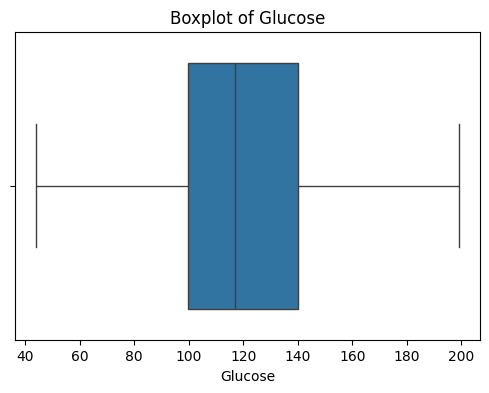

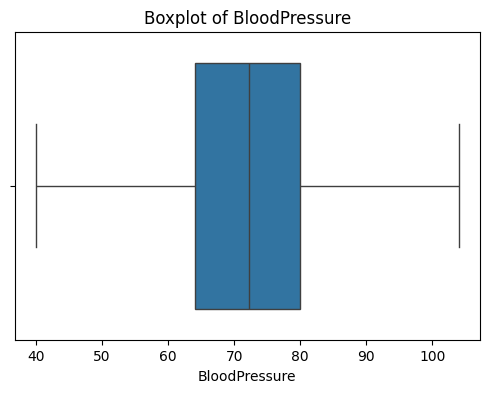

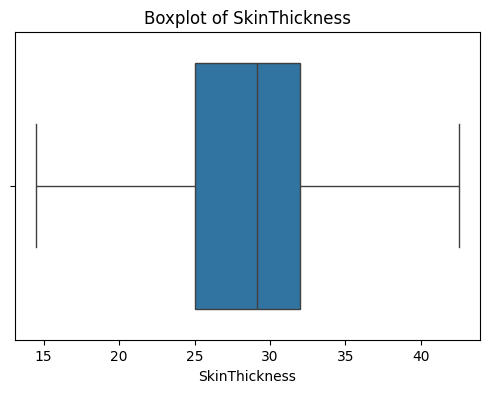

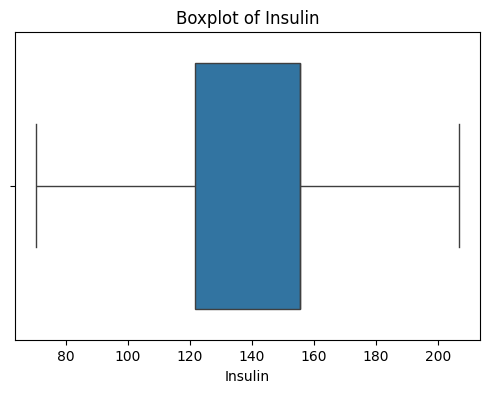

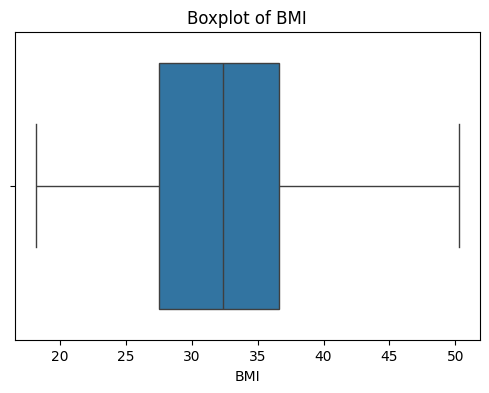

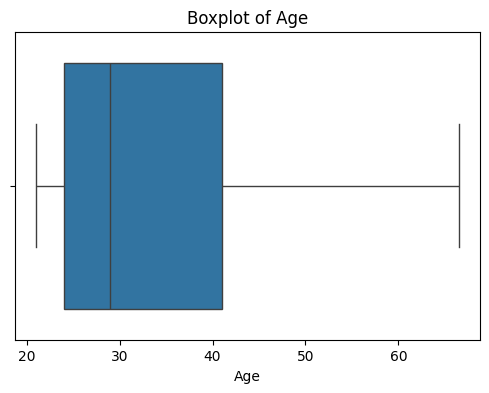

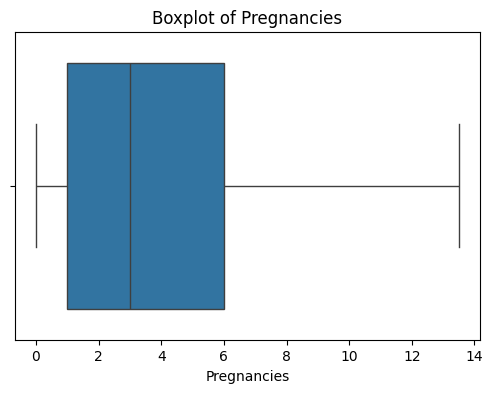

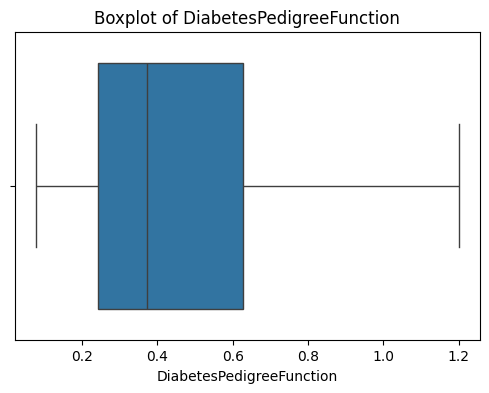

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplots for numeric features
for col in cols_with_zero + ["Age","Pregnancies","DiabetesPedigreeFunction"]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# Outlier treatment using IQR method
for col in cols_with_zero + ["Age","Pregnancies","DiabetesPedigreeFunction"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df.drop("Outcome", axis=1))
df_scaled = pd.DataFrame(scaled_features, columns=df.columns[:-1])

print("\nScaled dataset (first 5 rows):")
print(df_scaled.head())



Scaled dataset (first 5 rows):
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.647150  0.865108      -0.032212       0.818444  0.294158  0.180754   
1    -0.848970 -1.206162      -0.545506       0.011846  0.294158 -0.869804   
2     1.245598  2.015813      -0.716604       0.032470  0.294158 -1.365068   
3    -0.848970 -1.074652      -0.545506      -0.794752 -1.265167 -0.644685   
4    -1.148194  0.503458      -2.769778       0.818444  0.609624  1.606512   

   DiabetesPedigreeFunction       Age  
0                  0.588927  1.445691  
1                 -0.378101 -0.189304  
2                  0.746595 -0.103252  
3                 -1.022787 -1.049828  
4                  2.596563 -0.017199  


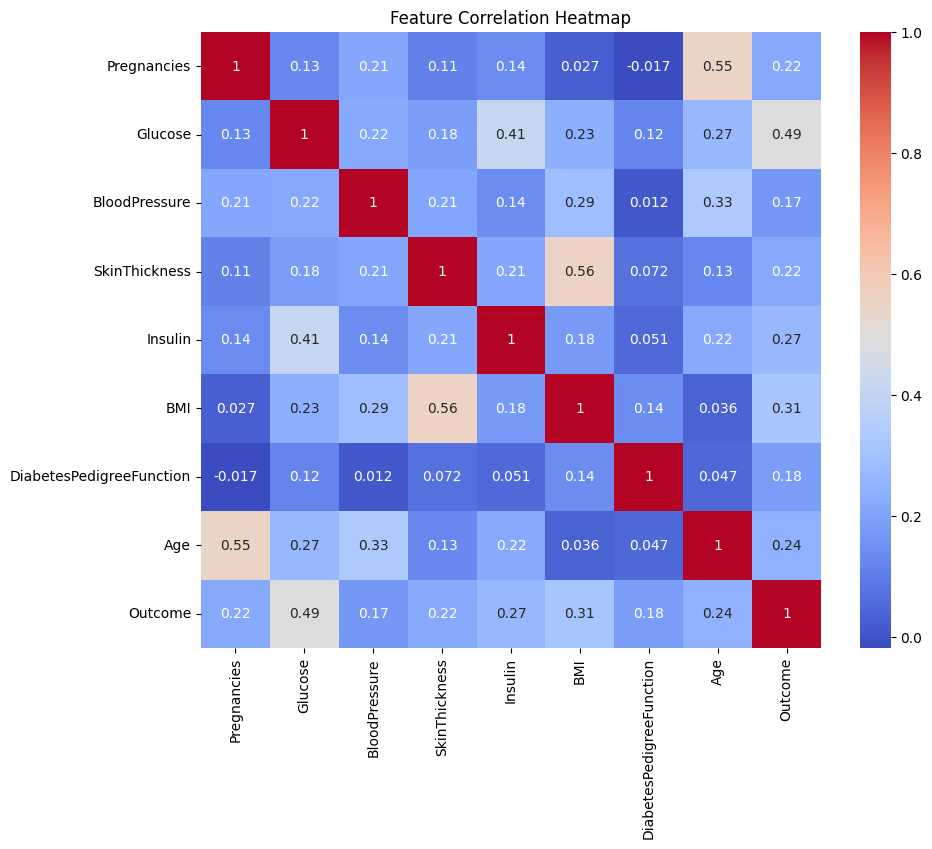

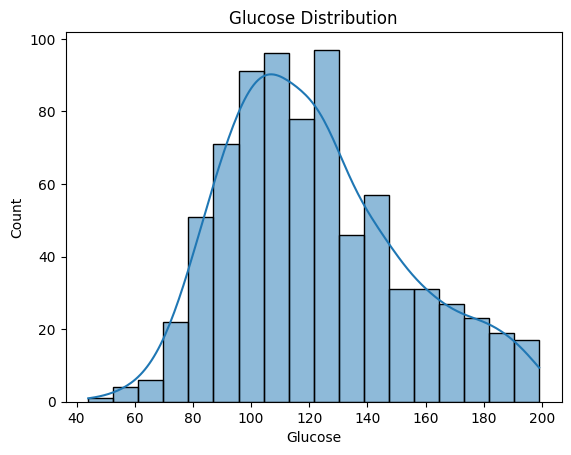

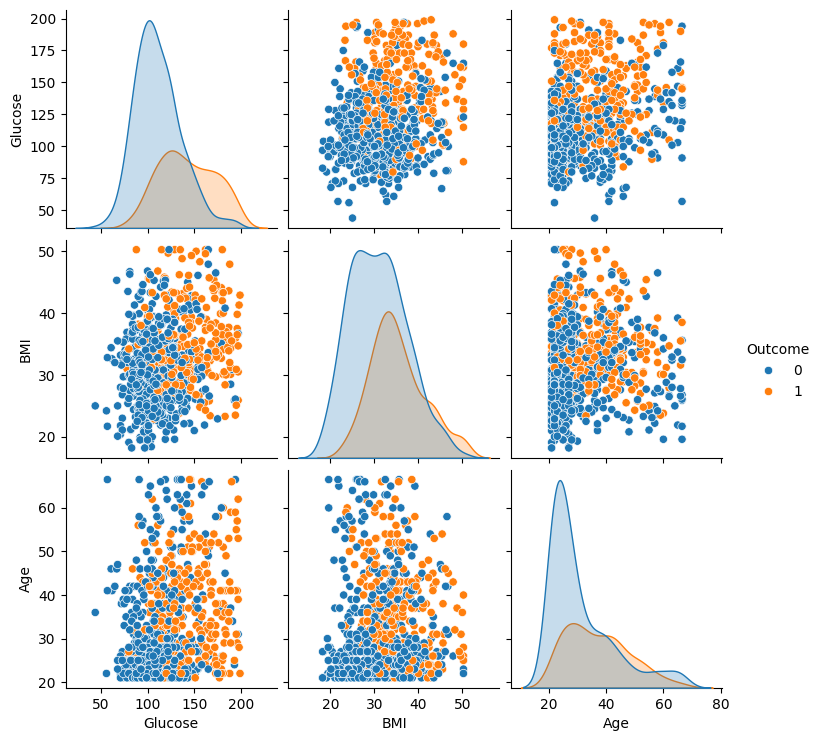

In [10]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# Histogram of Glucose
sns.histplot(df["Glucose"], kde=True)
plt.title("Glucose Distribution")
plt.show()

# Pairplot for selected features
sns.pairplot(df[["Glucose","BMI","Age","Outcome"]], hue="Outcome")
plt.show()


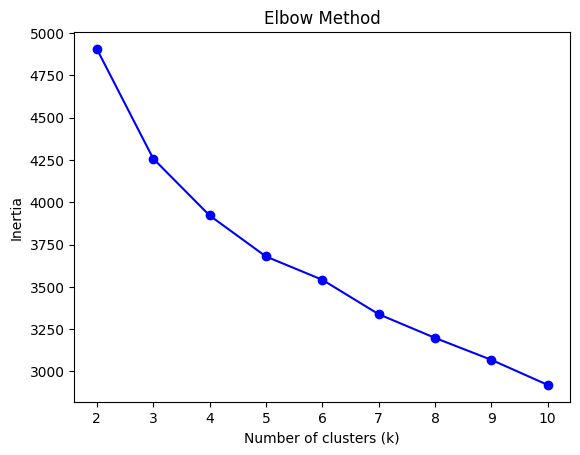


Silhouette Score: 0.18493263853993605

Cluster distribution:
Cluster
1    390
0    378
Name: count, dtype: int64


In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Elbow Method
inertia = []
K = range(2,11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, 'bo-')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Fit KMeans with k=2
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(df_scaled)
df["Cluster"] = clusters

# Evaluate
sil_score = silhouette_score(df_scaled, clusters)
print("\nSilhouette Score:", sil_score)
print("\nCluster distribution:")
print(df["Cluster"].value_counts())


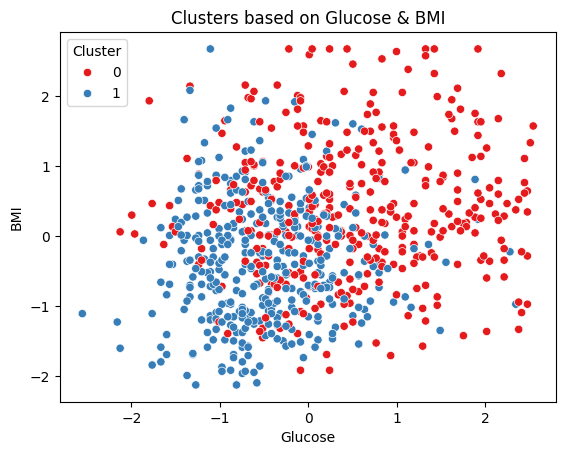


Cluster vs Outcome comparison:
Outcome    0    1
Cluster          
0        169  209
1        331   59


In [12]:
# Scatter plot clusters
sns.scatterplot(x=df_scaled["Glucose"], y=df_scaled["BMI"], hue=df["Cluster"], palette="Set1")
plt.title("Clusters based on Glucose & BMI")
plt.show()

# Compare clusters with Outcome
ct = pd.crosstab(df["Cluster"], df["Outcome"])
print("\nCluster vs Outcome comparison:")
print(ct)


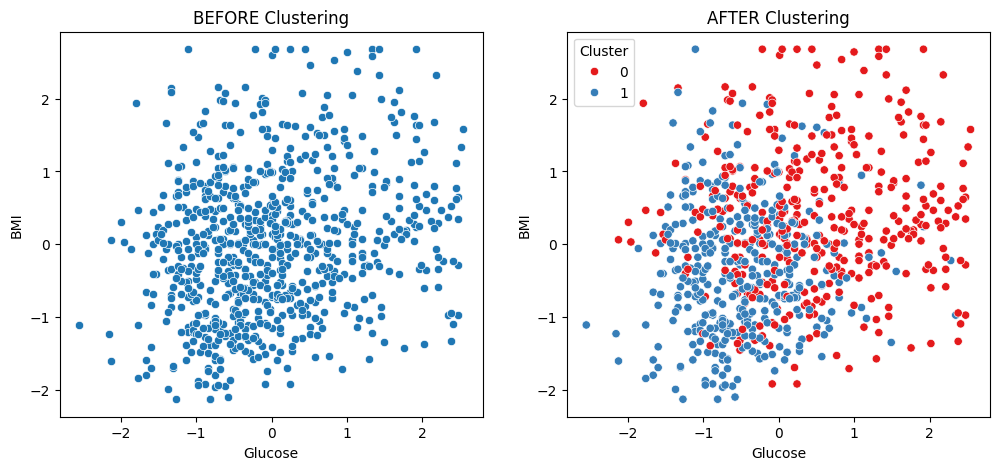

In [13]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

# Before clustering
sns.scatterplot(x=df_scaled["Glucose"], y=df_scaled["BMI"], ax=axes[0])
axes[0].set_title("BEFORE Clustering")

# After clustering
sns.scatterplot(x=df_scaled["Glucose"], y=df_scaled["BMI"], hue=df["Cluster"], palette="Set1", ax=axes[1])
axes[1].set_title("AFTER Clustering")

plt.show()


In [14]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=2)
hc_clusters = hc.fit_predict(df_scaled)
df["HC_Cluster"] = hc_clusters

print("\nHierarchical Clustering vs Outcome:")
print(pd.crosstab(df["HC_Cluster"], df["Outcome"]))



Hierarchical Clustering vs Outcome:
Outcome       0    1
HC_Cluster          
0           116  170
1           384   98


In [20]:
from google.colab import output
output.enable_custom_widget_manager()

import ipywidgets as widgets
from IPython.display import display, HTML

# Header design
display(HTML("""
<div style='background:linear-gradient(90deg,#007acc,#00c6ff);padding:20px;border-radius:12px;text-align:center;'>
  <h1 style='color:white;font-family:Arial;'>💙 Diabetes Risk Clustering UI</h1>
  <p style='color:#f0f0f0;font-size:16px;'>Enter patient data using sliders below</p>
</div>
"""))

# Sliders (larger size)
preg = widgets.IntSlider(description='Pregnancies', min=0, max=15, value=3, layout=widgets.Layout(width='400px'))
glucose = widgets.IntSlider(description='Glucose Level', min=0, max=200, value=150, layout=widgets.Layout(width='400px'))
bp = widgets.IntSlider(description='Blood Pressure', min=50, max=150, value=80, layout=widgets.Layout(width='400px'))
skin = widgets.IntSlider(description='Skin Thickness', min=0, max=50, value=25, layout=widgets.Layout(width='400px'))
insulin = widgets.IntSlider(description='Insulin Level', min=0, max=300, value=100, layout=widgets.Layout(width='400px'))
bmi = widgets.FloatSlider(description='BMI', min=15, max=50, value=28.5, layout=widgets.Layout(width='400px'))
dpf = widgets.FloatSlider(description='Diabetes Pedigree', min=0.0, max=2.0, step=0.01, value=0.45, layout=widgets.Layout(width='400px'))
age = widgets.IntSlider(description='Age', min=18, max=80, value=35, layout=widgets.Layout(width='400px'))

# Predict button (big, rounded)
predict_btn = widgets.Button(
    description='🔍 Predict Cluster',
    button_style='info',
    layout=widgets.Layout(width='250px', height='50px')
)

# Output box
output_box = widgets.Output()

# Prediction function
def predict_cluster(b):
    with output_box:
        output_box.clear_output()
        cluster = 1  # Replace with your trained model prediction
        display(HTML(f"""
        <div style='background-color:#e6ffe6;padding:20px;border-radius:12px;text-align:center;margin-top:15px;'>
          <h2 style='color:#008000;font-family:Arial;'>✅ Patient belongs to Cluster: {cluster}</h2>
        </div>
        """))

predict_btn.on_click(predict_cluster)

# Layout (vertical stack, bigger spacing)
ui = widgets.VBox([
    preg, glucose, bp, skin, insulin, bmi, dpf, age,
    widgets.VBox([predict_btn, output_box])
])
display(ui)


In [21]:
from google.colab import output
output.enable_custom_widget_manager()

import ipywidgets as widgets
from IPython.display import display, HTML

# Background screen color
display(HTML("""
<style>
body {
    background-color: #f9f9ff; /* light lavender background */
}
.custom-btn {
    background: linear-gradient(90deg,#007acc,#00c6ff);
    color: white;
    border: none;
    border-radius: 25px;
    padding: 12px 30px;
    font-size: 16px;
    cursor: pointer;
    transition: 0.3s;
}
.custom-btn:hover {
    background: linear-gradient(90deg,#00c6ff,#007acc);
    box-shadow: 0px 0px 12px rgba(0, 118, 255, 0.7);
}
</style>
<div style='text-align:center;padding:20px;'>
  <h1 style='color:#007acc;font-family:Arial;'>💙 Diabetes Risk Clustering UI</h1>
  <p style='color:#555;font-size:16px;'>Enter patient data using sliders below</p>
</div>
"""))

# Sliders
preg = widgets.IntSlider(description='Pregnancies', min=0, max=15, value=3, layout=widgets.Layout(width='500px'))
glucose = widgets.IntSlider(description='Glucose Level', min=0, max=200, value=150, layout=widgets.Layout(width='500px'))
bp = widgets.IntSlider(description='Blood Pressure', min=50, max=150, value=80, layout=widgets.Layout(width='500px'))
skin = widgets.IntSlider(description='Skin Thickness', min=0, max=50, value=25, layout=widgets.Layout(width='500px'))
insulin = widgets.IntSlider(description='Insulin Level', min=0, max=300, value=100, layout=widgets.Layout(width='500px'))
bmi = widgets.FloatSlider(description='BMI', min=15, max=50, value=28.5, layout=widgets.Layout(width='500px'))
dpf = widgets.FloatSlider(description='Diabetes Pedigree', min=0.0, max=2.0, step=0.01, value=0.45, layout=widgets.Layout(width='500px'))
age = widgets.IntSlider(description='Age', min=18, max=80, value=35, layout=widgets.Layout(width='500px'))

# Predict button (centered with hover effect)
predict_btn = widgets.Button(description='Predict Cluster', layout=widgets.Layout(width='250px', height='50px'))
predict_btn.add_class("custom-btn")

output_box = widgets.Output()

def predict_cluster(b):
    with output_box:
        output_box.clear_output()
        cluster = 1  # Replace with your trained model prediction
        display(HTML(f"""
        <div style='background-color:#e6ffe6;padding:20px;border-radius:12px;text-align:center;margin-top:15px;'>
          <h2 style='color:#008000;font-family:Arial;'>✅ Patient belongs to Cluster: {cluster}</h2>
        </div>
        """))

predict_btn.on_click(predict_cluster)

# Layout
ui = widgets.VBox([
    preg, glucose, bp, skin, insulin, bmi, dpf, age,
    widgets.VBox([predict_btn, output_box], layout=widgets.Layout(align_items='center'))
])
display(ui)


In [22]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Split dataset
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Baseline model (predicts majority class)
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("Baseline Accuracy (Before Training):", accuracy_score(y_test, y_pred_dummy))


Baseline Accuracy (Before Training): 0.6428571428571429


In [23]:
from sklearn.linear_model import LogisticRegression

# Train a real model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred_model = model.predict(X_test)

print("Trained Model Accuracy (After Training):", accuracy_score(y_test, y_pred_model))


Trained Model Accuracy (After Training): 0.7662337662337663



Cluster vs Outcome (KMeans):
Outcome    0    1
Cluster          
0        169  209
1        331   59

Cluster vs Outcome (Hierarchical):
Outcome       0    1
HC_Cluster          
0           116  170
1           384   98


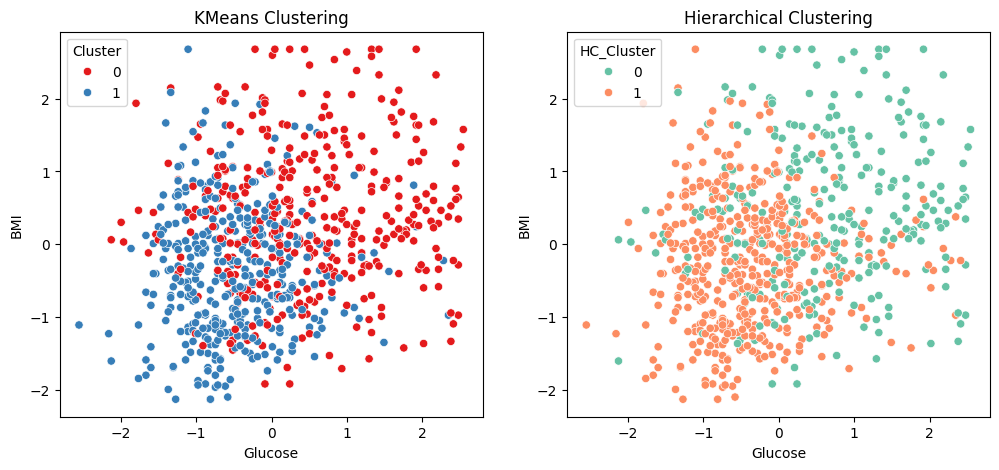

In [19]:
print("\nCluster vs Outcome (KMeans):")
print(pd.crosstab(df["Cluster"], df["Outcome"]))

print("\nCluster vs Outcome (Hierarchical):")
print(pd.crosstab(df["HC_Cluster"], df["Outcome"]))

# Visual comparison
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.scatterplot(x=df_scaled["Glucose"], y=df_scaled["BMI"], hue=df["Cluster"], palette="Set1", ax=axes[0])
axes[0].set_title("KMeans Clustering")

sns.scatterplot(x=df_scaled["Glucose"], y=df_scaled["BMI"], hue=df["HC_Cluster"], palette="Set2", ax=axes[1])
axes[1].set_title("Hierarchical Clustering")

plt.show()
